# File 3 — Lifestyle Construction

Replaces the old **HR-anomaly detection** (context baseline + GCN-DOMINANT). The professor wants the
subject's **lifestyle**, not per-episode anomaly flags. This notebook builds the **bottom half of the
p3/9 diagram** — *Personal Lifestyle Semantic Construction → Lifestyle KG → lifestyle map* — from the
episode timeline produced by File 2.

**Flow:** episodes → **SubjectContext** (who-is-this-person, kept as a *prior*) → **Stage A** the LLM
enriches each episode's context → **Stage B** a self-supervised Transformer encodes each day →
lifestyle **states** (KG) + **lifestyle map**.

**Guardrails:** descriptive only (no anomaly/health judgment); *code measures, the LLM names*;
seeded/CPU/deterministic; offline-first (Gemini optional, deterministic fallback). Engine lives in
`notebooks/lifestyle_construction/` (validated: demo ARI=1.0; LLM enrichment measurably improves
seasonal recovery). **File 1 & 2 unchanged;** the old anomaly notebook is archived in
`notebooks/_archive/03_baseline_gnn_anomaly.ipynb`.

## 1. Setup & load episodes

In [1]:
import os, sys, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

TZ = "Australia/Adelaide"
ROOT = r"C:\Project\Apple Health Data"
NB_DIR = os.path.join(ROOT, "notebooks")
PROC_DIR = os.path.join(ROOT, "data", "processed")
for d in (os.path.join(NB_DIR, "lifestyle_construction"), os.path.join(NB_DIR, "context_baseline")):
    if d not in sys.path:
        sys.path.insert(0, d)

OFFLINE = False   # False = use Gemini (cache is warm) for Stage A; True = deterministic labels only

ep = pd.read_parquet(os.path.join(PROC_DIR, "behavioral_episodes.parquet"))
if ep["datetime"].dt.tz is None:
    ep["datetime"] = ep["datetime"].dt.tz_localize(TZ)
print(f"episodes: {len(ep):,}  days: {ep['datetime'].dt.date.nunique():,}  "
      f"rest: {(~ep['is_workout']).sum():,}  workout: {ep['is_workout'].sum():,}")

episodes: 104,565  days: 1,761  rest: 103,644  workout: 921


## 2. Subject context — *who is this person* (kept as a prior)

The old File 3 used this to set an anomaly baseline; here it is kept only as a **prior** attached to
the lifestyle map (age band, fitness, home climate). It is external meta-information — the pipeline
stays generic and never decides the context itself.

In [2]:
from context_providers import build_subject_context, load_frames, attach_weather

USER_CONTEXT = {
    "age_band": "40_49",          # external meta-information (subject is 40)
    "sex": "male",
    "health_conditions": "none",
    "goal": "general_health",
}
frames = load_frames()
ep = attach_weather(ep, frames.get("weather"))   # belt-and-suspenders weather (File 2 already 100%)
est = build_subject_context(frames, user=USER_CONTEXT)
print(est.report())

def _priors(est):
    fields = ["age_band", "sex", "fitness_level", "home_climate", "occupation",
              "heart_health", "sleep", "health_conditions", "age_years"]
    p = {}
    for f in fields:
        v = getattr(est.context, f, None)
        if v is None:
            continue
        p[f] = ", ".join(map(str, v)) if isinstance(v, (list, tuple)) else str(v)
    # full artifacts under *_detail keys so they never clobber the scalar fields above
    for key, path in [("global_context_detail", os.path.join(ROOT, "results", "context_baseline", "global_context.json")),
                      ("home_climate_detail", os.path.join(ROOT, "results", "location_context", "home_climate.json"))]:
        if os.path.exists(path):
            try:
                p[key] = json.load(open(path))
            except Exception:
                pass
    return p

priors = _priors(est)
print("\nlifestyle priors:", {k: v for k, v in priors.items() if not k.endswith("_detail")})

  age_band               = 40_49            conf=1.00  [user] user-provided (overrides prediction)
  fitness_level          = recreational     conf=0.80  [predicted] HRR60~19bpm/34 exertion workouts; 1.2 sessions/wk, ~39min/wk
  home_climate           = temperate        conf=0.90  [predicted] mean_temp~15.7C, humidity~66%, warm_frac=0.03, home=Gamma Crescent, Panorama
  fitness_resting_report = recreational     conf=0.90  [predicted] REPORT-ONLY (not used for band) - resting_HR~74 (non-workout avg_hr p10); chart=average [male 36_45]
  sex                    = male             conf=1.00  [user] user-provided
  health_conditions      = none             conf=1.00  [user] user-provided
  goal                   = general_health   conf=1.00  [user] user-provided
  occupation             = unknown          conf=0.00  [predicted] not provided (no data predictor)
  sleep                  = unknown          conf=0.00  [predicted] not provided (no data predictor)
  heart_health           = unknow

## 3. Stage A — LLM context enrichment

Code builds a compact per-episode **signature** (is_workout, activity, place, hour-bucket, weekday,
HR-band vs the subject's own baseline, weather band); the 104,565 episodes collapse to a few hundred
signatures, and Gemini (temp=0, cached) names each — real enrichment, not the File-2 "normalize only".
Every episode carries `enrich_source` so a deterministic fallback is never reported as an LLM result.

In [3]:
import episode_enrichment as ea

enr = ea.run(offline=OFFLINE)
ep_enriched = enr.episodes
print("enrich source :", enr.meta["enrich_source_episodes"], "| used LLM:", enr.meta["used_llm"])
print("signatures    :", enr.meta["n_signatures"])
print("activity_context:", enr.meta["activity_context_dist"])

enrich source : {'llm': 104565} | used LLM: True
signatures    : 326
activity_context: {'daytime_rest': 61839, 'evening_rest': 35733, 'overnight_rest': 6074, 'active_workout': 919}


## 4. Stage B — build the lifestyle (day embeddings → states → KG → map)

A self-supervised masked-reconstruction Transformer encodes each **day** (its episodes in 96 15-min
slots) into an embedding; KMeans groups days into lifestyle **states**; transitions form the KG and the
per-state attributes + weekly/seasonal layout form the lifestyle **map**. Runs both `enriched` and
`raw` feature modes plus a hand-crafted baseline for the honest validation below.

In [4]:
import lifestyle_construction as lc

EPOCHS = 12
out = lc.run_and_save(ep_enriched, priors=priors, epochs=EPOCHS)
res, eval_df = out["primary"], out["eval"]
print(f"days: {len(res.labels):,} | states (k): {res.k} | silhouette: {res.silhouette}\n")
print("lifestyle states:")
print(res.nodes.to_string(index=False))

days: 1,761 | states (k): 3 | silhouette: 0.287

lifestyle states:
 state  n_days  median_hr  weekday_frac  workout_day_frac  median_wear_slots  top_month              name
     0     683       85.8          0.73              0.07                 59          7   restful_weekday
     1     820       86.6          0.71              0.15                 58          3 high_tone_weekday
     2     258       87.5          0.71              0.14                 58          1 high_tone_weekday


### Validation (honest — no lifestyle ground truth)

Clusters are scored against **derivable** structure never used as a target: `month`/`season` and
`workout_day` (clean); `weekday` is reported but flagged *dependent* (time-of-day leaks via slot
position). AMI = adjusted mutual information (higher = recovers more real structure).

In [5]:
cols = ["arm", "k", "silhouette", "month_ami", "season_ami", "workout_day_ami", "weekday_ami_DEPENDENT"]
print(eval_df[cols].to_string(index=False))
print("\nReading: LLM enrichment lifts seasonal recovery over raw & baseline; the aggregate baseline "
      "still wins workout_day (day-pooling dilutes the ~900 rare workout episodes).")

                 arm  k  silhouette  month_ami  season_ami  workout_day_ami  weekday_ami_DEPENDENT
transformer_enriched  3      0.2870     0.1674      0.1915           0.0084                -0.0004
  aggregate_baseline  3         NaN     0.0278      0.0225           0.3167                 0.0105
     transformer_raw  3      0.2956     0.1172      0.1357           0.0516                 0.0017

Reading: LLM enrichment lifts seasonal recovery over raw & baseline; the aggregate baseline still wins workout_day (day-pooling dilutes the ~900 rare workout episodes).


## 5. Visualise the lifestyle

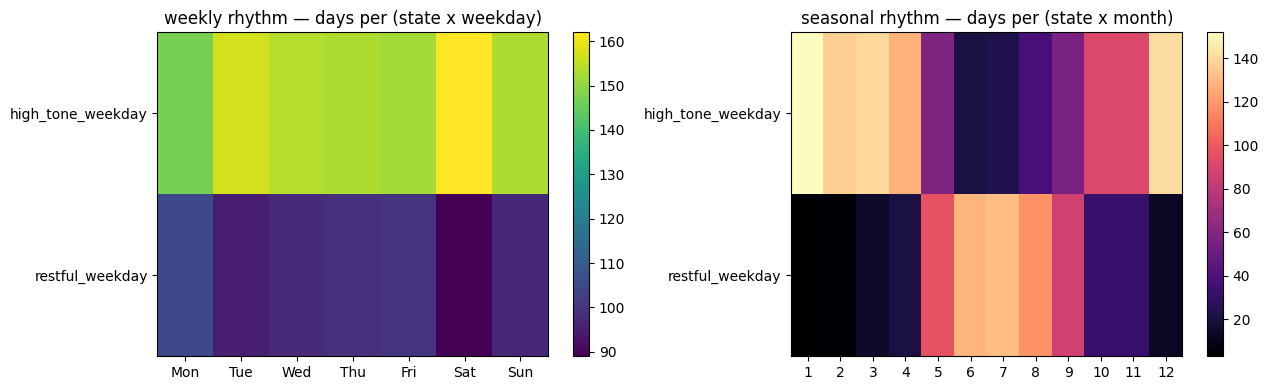

In [6]:
aux = res.extra["aux"].copy()
name_of = dict(zip(res.nodes["state"], res.nodes["name"]))
aux["state_name"] = pd.Series(res.labels, index=aux.index).map(name_of)

wk = aux.groupby(["state_name", "dow"]).size().unstack(fill_value=0)
mo = aux.groupby(["state_name", "month"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im0 = ax[0].imshow(wk.values, aspect="auto", cmap="viridis")
ax[0].set_yticks(range(len(wk.index))); ax[0].set_yticklabels(wk.index)
ax[0].set_xticks(range(7)); ax[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[0].set_title("weekly rhythm — days per (state x weekday)"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(mo.values, aspect="auto", cmap="magma")
ax[1].set_yticks(range(len(mo.index))); ax[1].set_yticklabels(mo.index)
ax[1].set_xticks(range(mo.shape[1])); ax[1].set_xticklabels(list(mo.columns))
ax[1].set_title("seasonal rhythm — days per (state x month)"); fig.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

## File 3 output summary

Written to `results/lifestyle_construction/`:
- `behavioral_episodes_enriched.parquet` — episodes + `activity_context` / `weather_ctx` /
  `workout_type_ctx` / `location_semantic` / `enrich_source` (Stage A)
- `day_embeddings.parquet` — one self-supervised embedding + assigned lifestyle state per day
- `lifestyle_kg_nodes.csv` / `lifestyle_kg_edges.csv` — lifestyle states (+attributes) & transitions
- `lifestyle_map.json` — state mix + weekly rhythm + yearly drift + subject priors
- `l1_proxy_eval.csv` — the honest enriched-vs-raw-vs-baseline validation table

**Replaced:** the old HR-anomaly detection (`standard_definitions.parquet`, GCN node/edge scores) is
gone from the main line (archived in `notebooks/_archive/`). **Next:** File 4 renders the lifestyle
report. Descriptive only — no anomaly or health claims.